# CBOW + Self-Attention Word2Vec -- Embedding Exploration

Loads the trained model from `models/checkpoint_step290000.pt` and:

1. t-SNE projection of word embeddings to 2D, plotted.
2. Nearest-neighbor queries for a handful of Darija words.
3. Runs `Embeddings/intrinsic_eval/scripts/evaluate_embeddings.py`'s word-similarity
   and analogy evaluation against this model.

Only the `input_embeddings` table is used as "the word vectors" -- the
self-attention/FFN block only ever processed *context windows* during
training (see `model.py`'s docstring: "only the input one is kept as 'the
word vectors' after training", standard word2vec convention). Run via the
GPU venv's kernel (CPU is fine here -- this notebook is just embedding
lookups + sklearn, no training).

In [1]:
from __future__ import annotations

import json
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE

import arabic_reshaper

ROOT = Path.cwd().resolve()
if ROOT.name == "word2vec_attention":
    WORD2VEC_DIR = ROOT
    ROOT = ROOT.parents[1]
else:
    WORD2VEC_DIR = ROOT / "Embeddings" / "word2vec_attention"

sys.path.insert(0, str(WORD2VEC_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
sys.path.insert(0, str(ROOT / "Embeddings" / "intrinsic_eval" / "scripts"))

from model import CBOWAttention  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

DATA_DIR = WORD2VEC_DIR / "data"
MODELS_DIR = WORD2VEC_DIR / "models"
checkpoints = sorted(MODELS_DIR.glob("checkpoint_step*.pt"), key=lambda p: int(p.stem.split("step")[-1]))
if not checkpoints:
    raise SystemExit(f"No checkpoint_step*.pt found in {MODELS_DIR}")
CHECKPOINT = checkpoints[-1]
print(f"Using checkpoint: {CHECKPOINT.name}")

device = torch.device("cpu")  # embedding lookups only -- GPU not needed

# Arabic-safe label rendering. Tahoma/Arial must come before Segoe UI in the
# fallback list (Segoe UI doesn't render arabic_reshaper's presentation-form
# glyphs joined -- confirmed by a rendered comparison).
plt.rcParams["font.family"] = ["Tahoma", "Arial", "Segoe UI", "DejaVu Sans"]

ARABIC_RE = re.compile(r"[؀-ۿݐ-ݿࢠ-ࣿﭐ-﷿ﹰ-﻿]")
LATIN_RE = re.compile(r"[a-zA-ZÀ-ɏ]")


def render_label(text: str) -> str:
    """Reshape Arabic-script text into joined presentation-form glyphs for
    correct matplotlib display. Deliberately does NOT also apply
    bidi.get_display() -- verified by a direct rendered A/B test against
    several known words ("خدمة", "السلام عليكم"): this environment's
    matplotlib/font stack already lays reshaped RTL glyphs out correctly on
    its own, so get_display's extra reversal on top produces a fully
    backwards word ("خدمة" -> "ةمدخ"). get_display is the textbook fix for
    renderers with NO bidi awareness at all -- this one isn't that case."""
    if ARABIC_RE.search(text):
        return arabic_reshaper.reshape(text)
    return text


def script_of(text: str) -> str:
    has_ar = bool(ARABIC_RE.search(text))
    has_lat = bool(LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


Using checkpoint: checkpoint_step675000.pt


In [2]:
# Load the tokenizer, checkpoint metadata, and the model.
meta = json.loads((DATA_DIR / "meta.json").read_text(encoding="utf-8"))
token_freq = {int(k): v for k, v in json.loads((DATA_DIR / "token_freq.json").read_text(encoding="utf-8")).items()}
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]

ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]
print(f"Checkpoint: step={ckpt['step']:,}, epoch={ckpt.get('epoch', '?')}, args={ckpt_args}")

model = CBOWAttention(
    vocab_size=vocab_size,
    embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"],
    ff_dim=ckpt_args["ff_dim"],
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

embedding_matrix = model.input_embeddings.weight.detach().cpu().numpy()  # (vocab_size, embed_dim)
print("embedding_matrix shape:", embedding_matrix.shape)

PAD_ID = 0  # verified against Tokenization/models/bpe/bpe_20000/vocab.json

Checkpoint: step=675,000, epoch=21, args={'epochs': 1000, 'target_pairs_per_batch': 4096, 'lr': 0.002, 'num_negative': 5, 'embed_dim': 128, 'num_heads': 4, 'ff_dim': 512, 'log_every': 200, 'checkpoint_every': 5000, 'resume': '../models/checkpoint_step345000.pt'}
embedding_matrix shape: (20000, 128)


In [3]:
def get_word_vector(word: str) -> np.ndarray | None:
    """Word-level vector: BPE-encode the word, mean-pool the input embeddings
    of its piece(s). A single-token word (common for short/frequent Darija
    words) is just a direct table lookup; a multi-piece word is averaged --
    same convention used for OOV handling elsewhere in the repo's embedding
    eval tooling (evaluate_embeddings.py expects `str -> np.ndarray | None`).
    """
    ids = [i for i in tok.encode(word) if i != PAD_ID and i < vocab_size]
    if not ids:
        return None
    return embedding_matrix[ids].mean(axis=0)


# Sanity check
v = get_word_vector("\u0628\u0632\u0627\u0641")  # bezzaf ("a lot")
print("vector shape:", None if v is None else v.shape)

vector shape: (128,)


## 1. t-SNE projection to 2D

Two groups, plotted together but colored separately:
- **frequent corpus words** -- the top-N most common whitespace-split words
  in the training corpus (`rows.jsonl`'s cleaned `text`, not BPE pieces).
  Multi-token words get their vector from `get_word_vector` (mean of their
  BPE pieces' embeddings), same as any other word.
- **curated Darija words** -- every word appearing in the intrinsic-eval
  word-similarity/analogy sets.

In [4]:
EVAL_DATA_DIR = ROOT / "Embeddings" / "intrinsic_eval" / "data"


def load_curated_words() -> list[str]:
    words: set[str] = set()
    with (EVAL_DATA_DIR / "word_similarity.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            words.add(row["word1"])
            
            words.add(row["word2"])
    with (EVAL_DATA_DIR / "analogy_pairs.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            cat = json.loads(line)
            for p in cat["pairs"]:
                words.add(p["word_a"])
                words.add(p["word_b"])
    return sorted(words)


curated_words = load_curated_words()
print(f"{len(curated_words)} unique curated words")


def count_corpus_words() -> "Counter[str]":
    """Word-level frequency count over the full corpus, splitting on
    whitespace (not BPE tokenization) -- per-word vectors already average
    BPE-piece embeddings via get_word_vector, so what's needed here is real
    corpus WORDS, matching how a person would split the text, not subword
    pieces."""
    from collections import Counter

    counts: Counter[str] = Counter()
    with (DATA_DIR / "rows.jsonl").open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            counts.update(json.loads(line)["text"].split())
            if (i + 1) % 1_000_000 == 0:
                print(f"  ...{i + 1:,} rows scanned")
    return counts


word_freq = count_corpus_words()
print(f"{len(word_freq):,} unique words across {sum(word_freq.values()):,} whitespace-split tokens")

TOP_N_FREQUENT_WORDS = 300  # more points in the plot itself
FREQUENT_WORD_POOL_SIZE = 10000  # candidate pool to sample from, each run

# Placeholders like [URL]/[MENTION] (see clean_text.py) and pure-digit/punctuation
# "words" aren't real vocabulary -- script_of() (arabic/latin) filters them out.
frequent_word_pool = [
    w for w, _ in word_freq.most_common(FREQUENT_WORD_POOL_SIZE * 3)
    if script_of(w) in ("arabic", "latin", "mixed")
][:FREQUENT_WORD_POOL_SIZE]

# Randomly sampled (no fixed seed) -- a different subset of the top
# FREQUENT_WORD_POOL_SIZE frequent words each time this cell runs, instead
# of always the exact same literal top-150. TSNE's own random_state below
# stays fixed -- that's about the projection algorithm's determinism given
# whatever points it's handed, not about which words get plotted.
frequent_words = random.sample(frequent_word_pool, min(TOP_N_FREQUENT_WORDS, len(frequent_word_pool)))
print(f"{len(frequent_words)} frequent corpus words (randomly sampled from top {len(frequent_word_pool)} by frequency)")

463 unique curated words


  ...1,000,000 rows scanned


  ...2,000,000 rows scanned


  ...3,000,000 rows scanned


  ...4,000,000 rows scanned


...

  ...6,000,000 rows scanned


  ...7,000,000 rows scanned


  ...8,000,000 rows scanned


5,538,155 unique words across 132,675,072 whitespace-split tokens


300 frequent corpus words (randomly sampled from top 10000 by frequency)


In [5]:
frequent_words_set = set(frequent_words)
curated_words_deduped = [w for w in curated_words if w not in frequent_words_set]

plot_vectors = []
plot_labels = []
plot_groups = []  # "frequent" or "curated"

for w in frequent_words:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("frequent")

for w in curated_words_deduped:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("curated")

X = np.stack(plot_vectors)
print(f"t-SNE input: {X.shape[0]} points, {X.shape[1]} dims")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
coords = tsne.fit_transform(X)

t-SNE input: 757 points, 128 dims


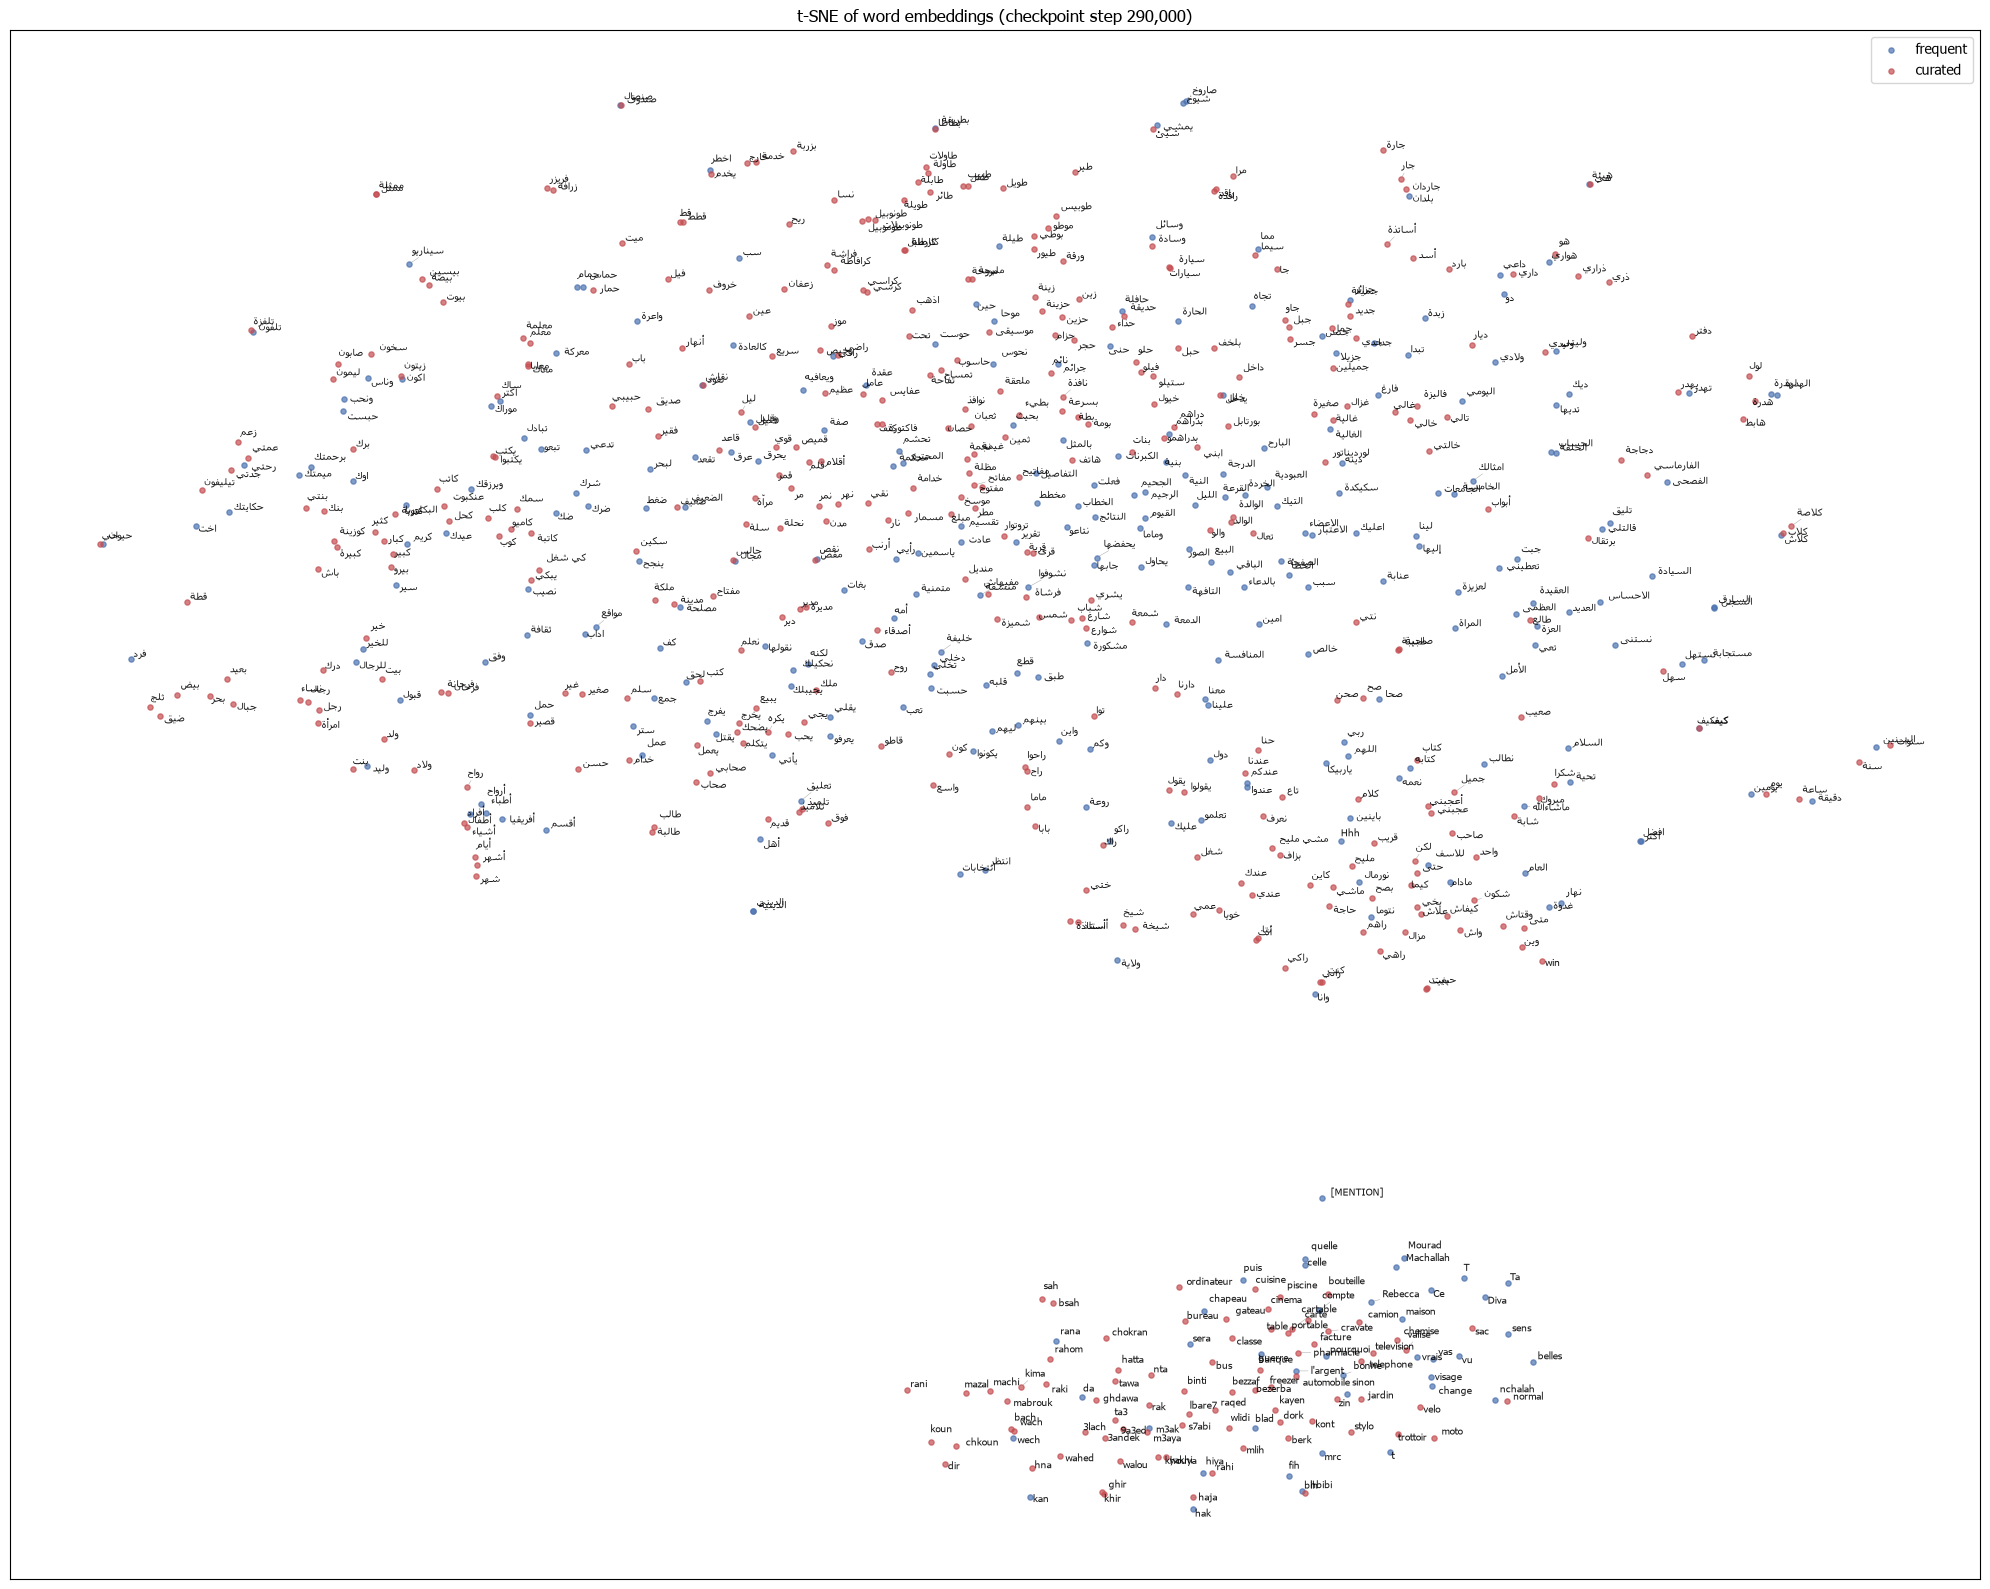

In [6]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(20, 16))

colors = {"frequent": "#4C72B0", "curated": "#C44E52"}
for group in ("frequent", "curated"):
    idx = [i for i, g in enumerate(plot_groups) if g == group]
    ax.scatter(coords[idx, 0], coords[idx, 1], s=14, color=colors[group], alpha=0.7, label=group)

# With ~600 points crammed into 2D, plain fixed-offset labels overlap and
# adjacent words visually merge into unreadable garbage (e.g. two labels
# sitting flush against each other read as one long fake "word"). adjustText
# repels overlapping labels apart and draws a thin line back to the true
# point, which plain annotate() offsets can't do.
texts = [
    ax.text(coords[i, 0], coords[i, 1], render_label(label), fontsize=7, alpha=0.9)
    for i, label in enumerate(plot_labels)
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4, alpha=0.6))

ax.set_title("t-SNE of word embeddings (checkpoint step 290,000)")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Nearest neighbors

Candidate pool = curated words ∪ frequent corpus words (the same points
plotted above, all real space-split words -- see `get_word_vector`),
ranked by cosine similarity to the query word's vector.

In [7]:
pool_matrix = X  # reuse the same vectors gathered for the t-SNE plot
pool_words = plot_labels
pool_norms = np.linalg.norm(pool_matrix, axis=1, keepdims=True)
pool_normed = pool_matrix / np.clip(pool_norms, 1e-9, None)


def nearest_neighbors(word: str, k: int = 10) -> list[tuple[str, float]]:
    qv = get_word_vector(word)
    if qv is None:
        return []
    qv = qv / max(np.linalg.norm(qv), 1e-9)
    sims = pool_normed @ qv
    order = np.argsort(-sims)
    results: list[tuple[str, float]] = []
    for i in order:
        w = pool_words[i]
        if w == word:
            continue
        results.append((w, float(sims[i])))
        if len(results) >= k:
            break
    return results


demo_words = ["\u0628\u0632\u0627\u0641", "\u062e\u062f\u0645\u0629", "\u0648\u0627\u0634", "\u062d\u0628\u064a\u0628\u064a", "\u0645\u0644\u064a\u062d", "\u0648\u0644\u062f", "\u0628\u0646\u062a", "\u0632\u064a\u0646"]
# bezzaf, khedma, wach, hbibi, mlih, wled, bnt, zin

for w in demo_words:
    neighbors = nearest_neighbors(w, k=10)
    print(f"\n{w}:")
    for nw, score in neighbors:
        print(f"  {score:.3f}  {nw}")


بزاف:
  0.543  ماشي
  0.525  حاجة
  0.519  كاين
  0.512  شابة
  0.507  اكثر
  0.503  مليح
  0.497  بصح
  0.466  راكي
  0.466  مشي مليح
  0.465  ماشاءالله

خدمة:
  0.756  خارج
  0.606  خالتي
  0.583  يخدم
  0.553  حزينة
  0.552  بزربة
  0.538  اخطر
  0.528  صديق
  0.513  خالص
  0.508  خالي
  0.464  زينة

واش:
  0.670  كيفاش
  0.622  علاش
  0.605  وقتاش
  0.598  شكون
  0.594  وين
  0.570  بصح
  0.568  كيما
  0.555  ماشي
  0.526  حبيت
  0.521  نتوما

حبيبي:
  0.517  صديق
  0.491  يبكي
  0.486  بيوت
  0.463  بيضة
  0.444  حبل
  0.441  نصيب
  0.435  صغير
  0.433  طبيبة
  0.422  صعيب
  0.413  يحب

مليح:
  0.645  بصح
  0.625  نورمال
  0.593  ماشي
  0.581  حاجة
  0.578  حتى
  0.577  شكرا
  0.577  شابة
  0.567  علاش
  0.557  كيفاش
  0.555  نتوما

ولد:
  0.617  رجل
  0.606  ولاد
  0.594  وليد
  0.586  حمل
  0.554  ضيق
  0.551  بحر
  0.533  بيض
  0.516  رجال
  0.493  فرحانة
  0.489  للرجال

بنت:
  0.601  وليد
  0.507  ولاد
  0.502  ولاية
  0.479  ولد
  0.477  راهي
  0.449  نعرف
  0.449  شابة
  0

## 3. Intrinsic evaluation (`evaluate_embeddings.py`)

Same word-similarity (Spearman correlation) and analogy (vector-arithmetic
nearest-neighbor) evaluation used by `Embeddings/intrinsic_eval`, wired to
this trained model's `get_word_vector`.

In [8]:
from evaluate_embeddings import evaluate_similarity, evaluate_analogies

print("=== Word similarity (Spearman correlation) ===")
sim = evaluate_similarity(get_word_vector)
print(
    f"Overall: r={sim['overall_spearman']:.4f} (p={sim['overall_p_value']:.4f}), "
    f"n={sim['n_pairs_scored']}, oov={sim['n_pairs_oov']}"
)
for cat, r in sim["by_category"].items():
    print(f"  {cat:<24} r={r['spearman']:.4f}  n={r['n_pairs']}  oov={r['n_oov']}")

print("\n=== Analogies (vector-arithmetic nearest-neighbor accuracy) ===")
ana = evaluate_analogies(get_word_vector)
print(f"Overall: acc={ana['overall_accuracy']:.4f}, n={ana['overall_n_questions']}")
for cat, r in ana["by_category"].items():
    print(f"  {cat:<24} acc={r['accuracy']:.4f}  n={r['n_questions']}  skipped_oov={r['n_skipped_oov']}")

=== Word similarity (Spearman correlation) ===
Overall: r=-0.2487 (p=0.0002), n=215, oov=0
  synonym                  r=0.4827  n=31  oov=0
  antonym                  r=-0.0694  n=29  oov=0
  cross_script             r=0.3740  n=49  oov=0
  code_switch              r=-0.0010  n=30  oov=0
  morphological_variant    r=-0.2593  n=36  oov=0
  unrelated                r=0.1409  n=40  oov=0

=== Analogies (vector-arithmetic nearest-neighbor accuracy) ===


Overall: acc=0.1900, n=4290
  gender                   acc=0.3299  n=870  skipped_oov=0
  singular_plural          acc=0.3230  n=870  skipped_oov=0
  script_transliteration   acc=0.0969  n=2550  skipped_oov=0


## 4. Sentiment word clustering (unsupervised, K-Means k=2)

Hand-picked positive/negative Darija sentiment words -- word-level
vectors from the same `get_word_vector` used above. K-Means (k=2,
**unsupervised**, no labels used for fitting) is fit directly on the raw
embedding vectors; t-SNE is only used afterward to visualize those same
vectors in 2D. Plotted two ways side by side -- colored by the
hand-assigned true label, and colored by the K-Means cluster assignment
-- so how well an unsupervised split recovers the sentiment split can be
judged both visually and via the Adjusted Rand Index (ARI: 0 = chance
agreement, 1 = perfect agreement with the true labels).

20 sentiment words, 128 dims
Adjusted Rand Index (true label vs K-Means cluster): 0.121


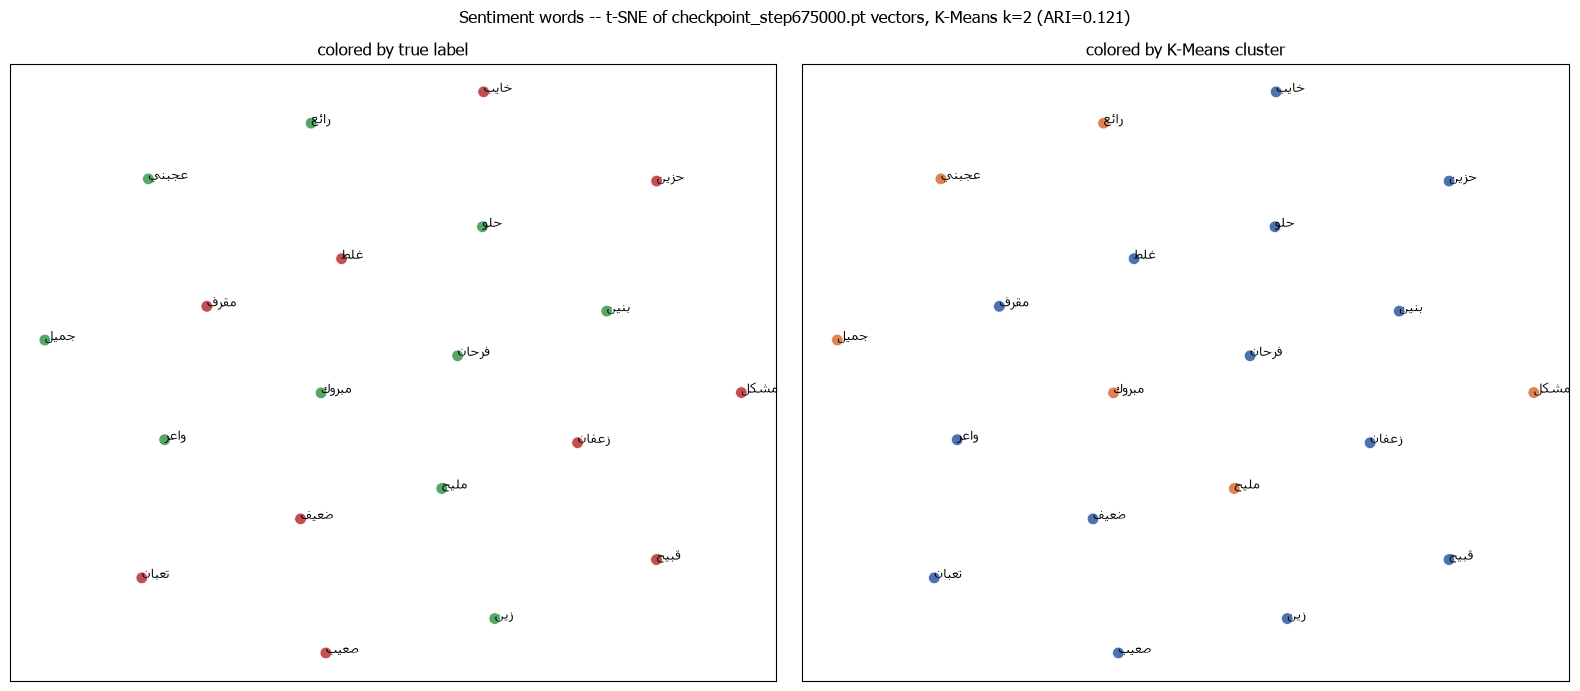

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

POSITIVE_WORDS = ["\u0645\u0644\u064a\u062d", "\u0632\u064a\u0646", "\u0641\u0631\u062d\u0627\u0646", "\u062d\u0644\u0648", "\u0639\u062c\u0628\u0646\u064a", "\u0631\u0627\u0626\u0639", "\u0645\u0628\u0631\u0648\u0643", "\u0628\u0646\u064a\u0646", "\u062c\u0645\u064a\u0644", "\u0648\u0627\u0639\u0631"]
# mlih, zin, farhan, hlou, 3ejbni, rai3, mabrouk, bnin, jmil, wa3er
NEGATIVE_WORDS = ["\u062e\u0627\u064a\u0628", "\u0642\u0628\u064a\u062d", "\u062d\u0632\u064a\u0646", "\u0632\u0639\u0641\u0627\u0646", "\u0645\u0634\u0643\u0644", "\u062a\u0639\u0628\u0627\u0646", "\u063a\u0644\u0637", "\u0635\u0639\u064a\u0628", "\u0645\u0642\u0631\u0641", "\u0636\u0639\u064a\u0641"]
# khayeb, qbih, hzin, za3fan, mochkel, t3ban, ghalt, s3ib, mqarref, dh3if


def build_word_group_vectors(groups: dict[str, list[str]]):
    """Flattens a {label: [words]} dict into (X, words, true_labels),
    dropping any word get_word_vector can't produce a vector for (fully
    OOV under the tokenizer -- shouldn't happen for BPE, kept as a guard).
    """
    vecs, words, labels = [], [], []
    for label, ws in groups.items():
        for w in ws:
            v = get_word_vector(w)
            if v is None:
                print(f"  skipping OOV: {w}")
                continue
            vecs.append(v)
            words.append(w)
            labels.append(label)
    return np.stack(vecs), words, labels


def plot_clustering(X, words, true_labels, true_colors, k, title):
    """Fits K-Means(k) on the raw vectors, projects the same vectors to 2D
    via t-SNE for visualization only, and plots true-label vs cluster-
    assignment side by side. Returns the fitted KMeans and the ARI.
    """
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    ari = adjusted_rand_score(true_labels, kmeans.labels_)
    print(f"Adjusted Rand Index (true label vs K-Means cluster): {ari:.3f}")

    perplexity = min(30, max(2, X.shape[0] - 1))
    coords = TSNE(n_components=2, random_state=42, perplexity=perplexity, init="pca").fit_transform(X)

    cluster_palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    panels = [
        (axes[0], [true_colors[l] for l in true_labels], "colored by true label"),
        (axes[1], [cluster_palette[c % len(cluster_palette)] for c in kmeans.labels_], "colored by K-Means cluster"),
    ]
    for ax, point_colors, subtitle in panels:
        ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=70, edgecolors="white", linewidths=0.5)
        for i, w in enumerate(words):
            ax.annotate(render_label(w), (coords[i, 0], coords[i, 1]), fontsize=9)
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f"{title} -- t-SNE of {CHECKPOINT.name} vectors, K-Means k={k} (ARI={ari:.3f})")
    plt.tight_layout()
    plt.show()
    return kmeans, ari


sent_X, sent_words, sent_true_labels = build_word_group_vectors(
    {"positive": POSITIVE_WORDS, "negative": NEGATIVE_WORDS}
)
print(f"{sent_X.shape[0]} sentiment words, {sent_X.shape[1]} dims")

sent_colors = {"positive": "#55A868", "negative": "#C44E52"}
sent_kmeans, sent_ari = plot_clustering(sent_X, sent_words, sent_true_labels, sent_colors, k=2, title="Sentiment words")


## 5. Named-entity-type word clustering (unsupervised, K-Means k=4)

Same idea, four categories instead of two: hand-picked Algerian person
names, locations, organizations, and time/date words. K-Means (k=4,
unsupervised) fit on the raw vectors, visualized with the same
true-label / cluster-assignment t-SNE pair as above.

32 entity words, 128 dims
Adjusted Rand Index (true label vs K-Means cluster): 0.012


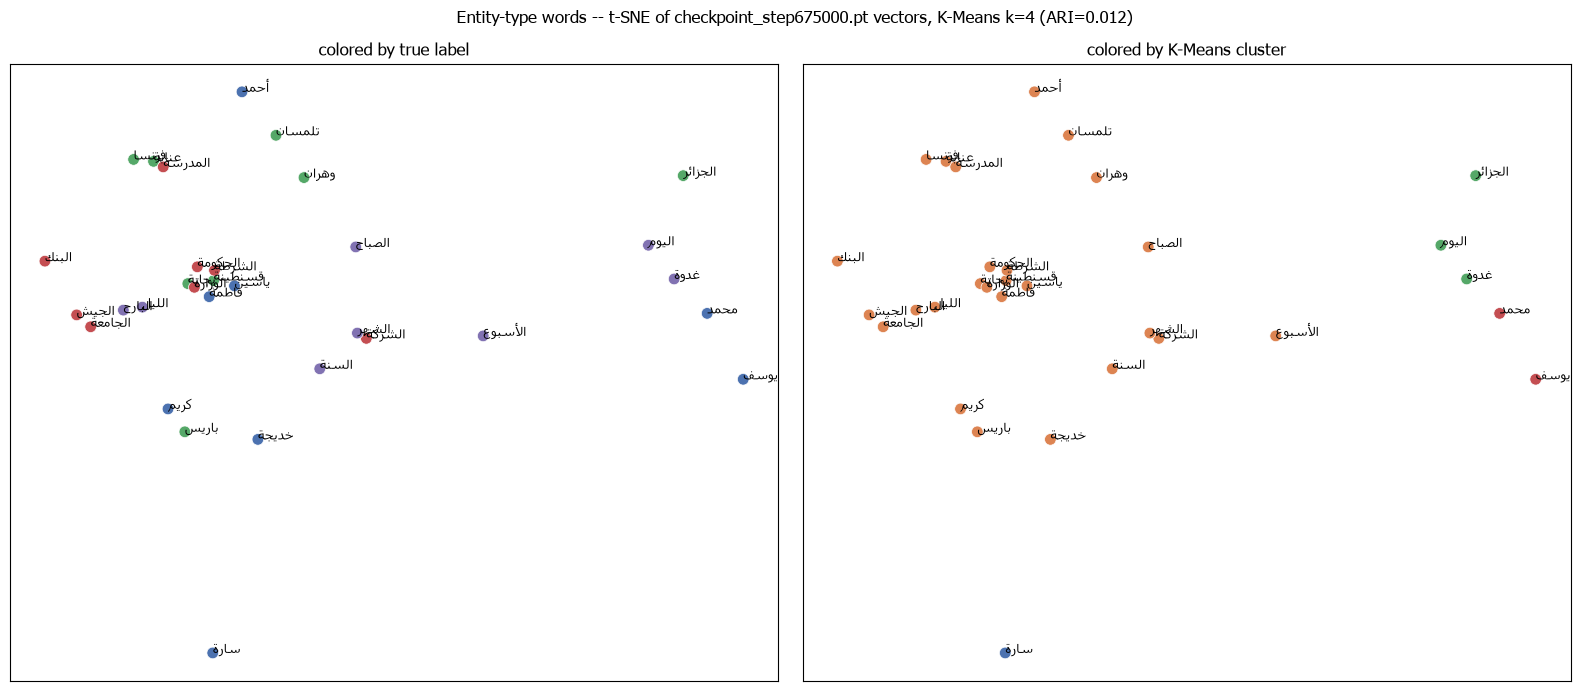

In [10]:
PERSON_WORDS = ["\u0645\u062d\u0645\u062f", "\u0623\u062d\u0645\u062f", "\u064a\u0648\u0633\u0641", "\u0633\u0627\u0631\u0629", "\u0641\u0627\u0637\u0645\u0629", "\u062e\u062f\u064a\u062c\u0629", "\u0643\u0631\u064a\u0645", "\u064a\u0627\u0633\u064a\u0646"]
# mohamed, ahmed, youcef, sara, fatima, khadija, karim, yacine
LOCATION_WORDS = ["\u0627\u0644\u062c\u0632\u0627\u0626\u0631", "\u0648\u0647\u0631\u0627\u0646", "\u0642\u0633\u0646\u0637\u064a\u0646\u0629", "\u0639\u0646\u0627\u0628\u0629", "\u062a\u0644\u0645\u0633\u0627\u0646", "\u0628\u062c\u0627\u064a\u0629", "\u0641\u0631\u0646\u0633\u0627", "\u0628\u0627\u0631\u064a\u0633"]
# el-djazair, wahran, qacentina, annaba, tlemcen, bejaia, france, paris
ORGANIZATION_WORDS = ["\u0627\u0644\u062d\u0643\u0648\u0645\u0629", "\u0627\u0644\u062c\u064a\u0634", "\u0627\u0644\u0634\u0631\u0637\u0629", "\u0627\u0644\u062c\u0627\u0645\u0639\u0629", "\u0627\u0644\u0648\u0632\u0627\u0631\u0629", "\u0627\u0644\u0628\u0646\u0643", "\u0627\u0644\u0634\u0631\u0643\u0629", "\u0627\u0644\u0645\u062f\u0631\u0633\u0629"]
# el-hokouma, el-jaych, e-chorta, el-jami3a, el-wizara, el-bank, e-charika, el-madrasa
TIME_DATE_WORDS = ["\u0627\u0644\u064a\u0648\u0645", "\u063a\u062f\u0648\u0629", "\u0627\u0644\u0628\u0627\u0631\u062d", "\u0627\u0644\u0635\u0628\u0627\u062d", "\u0627\u0644\u0644\u064a\u0644", "\u0627\u0644\u0623\u0633\u0628\u0648\u0639", "\u0627\u0644\u0634\u0647\u0631", "\u0627\u0644\u0633\u0646\u0629"]
# el-youm, ghdawa, el-bare7, e-sbah, el-lil, el-osbou3, e-chher, e-sena

ent_X, ent_words, ent_true_labels = build_word_group_vectors({
    "person": PERSON_WORDS,
    "location": LOCATION_WORDS,
    "organization": ORGANIZATION_WORDS,
    "time_date": TIME_DATE_WORDS,
})
print(f"{ent_X.shape[0]} entity words, {ent_X.shape[1]} dims")

ent_colors = {"person": "#4C72B0", "location": "#55A868", "organization": "#C44E52", "time_date": "#8172B2"}
ent_kmeans, ent_ari = plot_clustering(ent_X, ent_words, ent_true_labels, ent_colors, k=4, title="Entity-type words")
